In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
from pathlib import Path

freq_file = Path("Al2O3.freq")

with open(freq_file, "r") as f:
    for i in range(25):
        print(f"{i+1:03d}: {f.readline().rstrip()}")

001:  &plot nbnd=  30, nks= 211 /
002:             0.000000  0.000000  0.000000
003:    -9.6358   -9.6271   -1.3584  283.1951  355.0999  355.3268
004:   360.1871  361.7505  375.0525  390.5665  401.2512  401.3879
005:   415.7726  425.1306  425.1916  457.2340  510.2752  538.8058
006:   552.6865  552.7630  552.8884  567.7049  598.0253  603.8055
007:   605.7547  661.5086  715.0035  715.4909  719.2586  859.4972
008:             0.016647 -0.011511 -0.007871
009:    -4.4766    6.5290   12.1490  283.0935  354.7824  355.1243
010:   359.7589  361.8150  374.9318  390.9014  401.1113  401.4838
011:   416.4507  425.0399  425.3357  457.3316  510.0640  538.8010
012:   552.3129  552.6222  553.2070  567.5680  596.7770  603.8909
013:   606.9747  661.5020  715.0414  715.5053  719.2766  859.4168
014:             0.033295 -0.023022 -0.015742
015:    14.0776   15.0822   28.5627  282.7874  353.5522  354.8753
016:   358.5497  361.9310  374.6189  391.7819  400.5564  402.0546
017:   418.3187  424.6842  425.8686 

In [2]:
freq_file = './Al2O3.freq'#Path("Al2O3.freq")
nmodes = 30  # Al2O3 has 10 atoms, so 3N = 30 modes

q_dist = []
freqs = []

with open(freq_file, "r") as f:
    lines = f.readlines()

i = 0
while i < len(lines):
    parts = lines[i].split()

    # QE matdyn format usually has:
    # qx qy qz distance
    if len(parts) == 4:
        try:
            qx, qy, qz, x = map(float, parts)

            vals = []
            i += 1

            while i < len(lines):
                p = lines[i].split()

                # stop if next q-point line begins
                if len(p) == 4:
                    try:
                        float(p[0])
                        float(p[1])
                        float(p[2])
                        float(p[3])
                        break
                    except ValueError:
                        pass

                for item in p:
                    try:
                        vals.append(float(item))
                    except ValueError:
                        pass

                if len(vals) >= nmodes:
                    break

                i += 1

            if len(vals) >= nmodes:
                q_dist.append(x)
                freqs.append(vals[:nmodes])

        except ValueError:
            i += 1
    else:
        i += 1

q_dist = np.array(q_dist)
freqs = np.array(freqs)

print("Parsed q-points:", len(q_dist))
print("Parsed modes:", freqs.shape[1])
print("Minimum frequency:", freqs.min(), "cm^-1")
print("Maximum frequency:", freqs.max(), "cm^-1")

Parsed q-points: 0


IndexError: tuple index out of range

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import re

freq_file = "./Al2O3.freq"

with open(freq_file, "r") as f:
    lines = [line.strip() for line in f if line.strip()]

# Read nbnd and nks from first line
header = lines[0]
nbnd = int(re.search(r"nbnd=\s*(\d+)", header).group(1))
nks = int(re.search(r"nks=\s*(\d+)", header).group(1))

print("Number of bands:", nbnd)
print("Number of q-points:", nks)

q_points = []
freqs = []

i = 1
while i < len(lines):
    # q-point line: qx qy qz
    q = list(map(float, lines[i].split()))
    q_points.append(q)
    i += 1

    # collect nbnd frequencies
    vals = []
    while len(vals) < nbnd and i < len(lines):
        vals.extend([float(x) for x in lines[i].split()])
        i += 1

    freqs.append(vals[:nbnd])

q_points = np.array(q_points)
freqs = np.array(freqs)

print("Parsed q-points:", q_points.shape)
print("Parsed frequencies:", freqs.shape)
print("Minimum frequency:", freqs.min(), "cm^-1")
print("Maximum frequency:", freqs.max(), "cm^-1")

Number of bands: 30
Number of q-points: 211
Parsed q-points: (211, 3)
Parsed frequencies: (211, 30)
Minimum frequency: -9.6361 cm^-1
Maximum frequency: 859.4972 cm^-1


In [5]:
# Compute cumulative distance along q-path
dq = np.diff(q_points, axis=0)
distances = np.linalg.norm(dq, axis=1)

x = np.zeros(len(q_points))
x[1:] = np.cumsum(distances)

In [7]:
# Keep original frequencies for checking
freqs_raw = freqs.copy()

# Move negative frequencies to zero for plotting only
freqs_plot = freqs.copy()
freqs_plot[freqs_plot < 0] = 0.0

print("Minimum original frequency:", freqs_raw.min(), "cm^-1")
print("Minimum plotted frequency:", freqs_plot.min(), "cm^-1")
print("Number of negative values moved to zero:", np.sum(freqs_raw < 0))

Minimum original frequency: -9.6361 cm^-1
Minimum plotted frequency: 0.0 cm^-1
Number of negative values moved to zero: 10


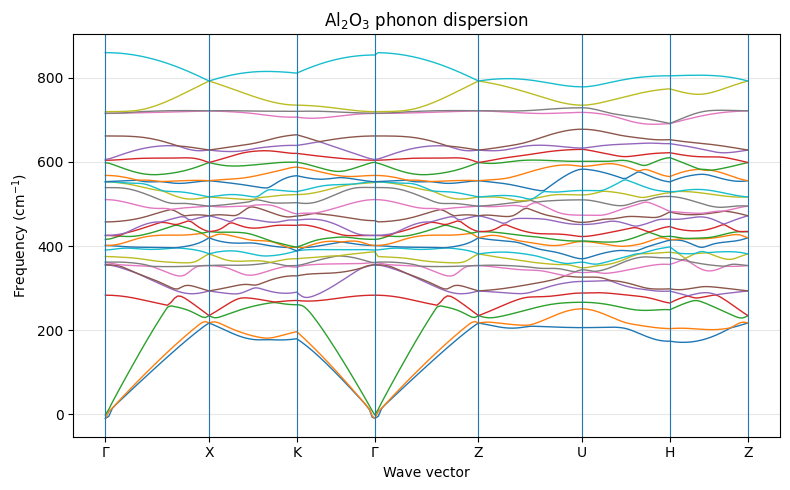

In [6]:
plt.figure(figsize=(8, 5))

for mode in range(nbnd):
    plt.plot(x, freqs[:, mode], linewidth=1)

# Your path from matdyn.in:
# Gamma -> X -> K -> Gamma -> Z -> U -> H -> Z
labels = [r"$\Gamma$", "X", "K", r"$\Gamma$", "Z", "U", "H", "Z"]

# You used 30 points per segment and 1 final endpoint
tick_indices = [0, 30, 60, 90, 120, 150, 180, len(x)-1]
tick_indices = [idx for idx in tick_indices if idx < len(x)]
tick_positions = [x[idx] for idx in tick_indices]

for xpos in tick_positions:
    plt.axvline(xpos, linewidth=0.8)

plt.xticks(tick_positions, labels[:len(tick_positions)])
plt.ylabel(r"Frequency (cm$^{-1}$)")
plt.xlabel("Wave vector")
plt.title(r"Al$_2$O$_3$ phonon dispersion")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

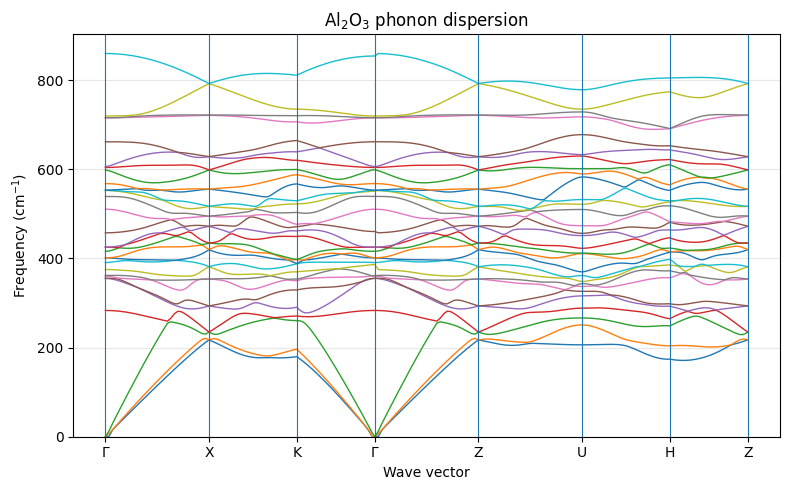

In [8]:
plt.figure(figsize=(8, 5))

for mode in range(nbnd):
    plt.plot(x, freqs_plot[:, mode], linewidth=1)

labels = [r"$\Gamma$", "X", "K", r"$\Gamma$", "Z", "U", "H", "Z"]

tick_indices = [0, 30, 60, 90, 120, 150, 180, len(x)-1]
tick_indices = [idx for idx in tick_indices if idx < len(x)]
tick_positions = [x[idx] for idx in tick_indices]

for xpos in tick_positions:
    plt.axvline(xpos, linewidth=0.8)

plt.xticks(tick_positions, labels[:len(tick_positions)])
plt.ylabel(r"Frequency (cm$^{-1}$)")
plt.xlabel("Wave vector")
plt.title(r"Al$_2$O$_3$ phonon dispersion")
plt.ylim(bottom=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import re

freq_file = "./Al2O3.freq"

with open(freq_file, "r") as f:
    lines = [line.strip() for line in f if line.strip()]

# Header
header = lines[0]
nbnd = int(re.search(r"nbnd=\s*(\d+)", header).group(1))
nks  = int(re.search(r"nks=\s*(\d+)", header).group(1))

print("Number of bands:", nbnd)
print("Number of q-points:", nks)

q_points = []
freqs = []

i = 1
while i < len(lines):
    # q-point
    q = list(map(float, lines[i].split()))
    q_points.append(q)
    i += 1

    # collect nbnd frequencies
    vals = []
    while len(vals) < nbnd and i < len(lines):
        vals.extend([float(x) for x in lines[i].split()])
        i += 1

    freqs.append(vals[:nbnd])

q_points = np.array(q_points)
freqs = np.array(freqs)

print("Parsed q-points:", q_points.shape)
print("Parsed frequencies:", freqs.shape)
print("Minimum frequency:", freqs.min(), "cm^-1")
print("Maximum frequency:", freqs.max(), "cm^-1")

Number of bands: 30
Number of q-points: 211
Parsed q-points: (211, 3)
Parsed frequencies: (211, 30)
Minimum frequency: -9.6361 cm^-1
Maximum frequency: 859.4972 cm^-1


In [18]:
# cumulative distance along the k-path
dq = np.diff(q_points, axis=0)
distances = np.linalg.norm(dq, axis=1)

x = np.zeros(len(q_points))
x[1:] = np.cumsum(distances)

# keep original data
freqs_raw = freqs.copy()

# for visualization only: clip negative frequencies to zero
freqs_plot = freqs.copy()
freqs_plot[freqs_plot < 0] = 0.0

print("Negative values moved to zero:", np.sum(freqs_raw < 0))

# # for visualization only: take absolute value of frequencies
# freqs_plot = np.abs(freqs.copy())

# print("Minimum original frequency:", freqs_raw.min(), "cm^-1")
# print("Minimum plotted frequency:", freqs_plot.min(), "cm^-1")
# print("Number of negative values converted:", np.sum(freqs_raw < 0))

Negative values moved to zero: 10


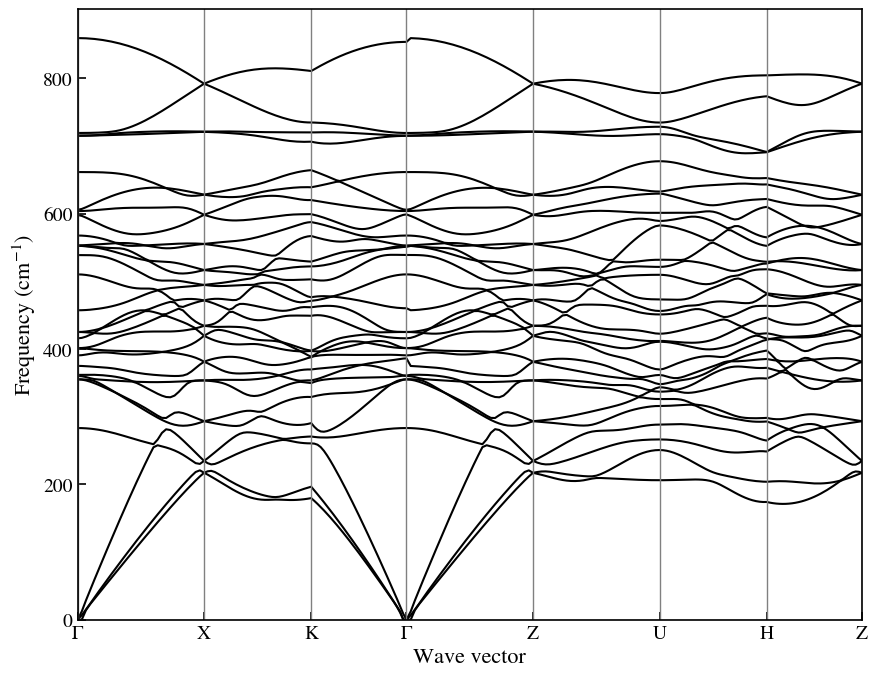

In [19]:
# publication-style settings
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.linewidth": 1.2,
})

fig, ax = plt.subplots(figsize=(9, 7))

# all branches same color
for mode in range(nbnd):
    ax.plot(x, freqs_plot[:, mode], color="black", linewidth=1.5)

# High-symmetry path labels
labels = [r"$\Gamma$", "X", "K", r"$\Gamma$", "Z", "U", "H", "Z"]

# Since you used 30 points per segment and 1 at the end
tick_indices = [0, 30, 60, 90, 120, 150, 180, len(x)-1]
tick_indices = [idx for idx in tick_indices if idx < len(x)]
tick_positions = [x[idx] for idx in tick_indices]

# vertical lines at high-symmetry points
for xpos in tick_positions:
    ax.axvline(x=xpos, color="gray", linewidth=1.0)

# horizontal line at zero
ax.axhline(y=0, color="gray", linewidth=1.0)

ax.set_xticks(tick_positions)
ax.set_xticklabels(labels[:len(tick_positions)])

ax.set_ylabel(r"Frequency (cm$^{-1}$)")
ax.set_xlabel("Wave vector")

# good for publication: often no title
# ax.set_title(r"Al$_2$O$_3$ phonon dispersion")

ax.set_xlim(x[0], x[-1])
ax.set_ylim(bottom=0)

# cleaner look
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)
ax.tick_params(direction="in", length=6, width=1.2)

plt.tight_layout()
plt.show()